In [226]:
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties import unumpy as unp
import scipy
from scipy.stats import sem

In [227]:
def SMD(u1,u2):
    return (u1.nominal_value - u2.nominal_value)/(np.sqrt(u1.std_dev**2 + u2.std_dev**2))


In [228]:
x = unp.uarray([1,2,3,4],1)


In [ ]:
VZ_Masse = ufloat(444,1) / 1000 # +- 1g
HZ_Masse = ufloat(443,1) / 1000 # +- 1g
Messfehler = 0.05 # mm
HZ_Durchmesser_Außen = ufloat(50,Messfehler) / 1000 # mm
HZ_Radius_Außen = HZ_Durchmesser_Außen / 2
HZ_Durchmesser_Innen = ufloat(40.6,Messfehler) / 1000
HZ_Radius_Innen = HZ_Durchmesser_Innen / 2
HZ_Wanddicke = 4.7

VZ_Durchmesser = ufloat(50.05,Messfehler) / 1000
VZ_Radius = VZ_Durchmesser / 2

In [265]:
Messfehler_lineal = 0.002 # Valide weil war schwer abzuschätzen + nd ganz gerade
Unterkannte_Platte_oben = ufloat(0.149,Messfehler_lineal)
Tisch_Distanz_Platte = ufloat(0.988,Messfehler_lineal)
tan_alpha = Unterkannte_Platte_oben / Tisch_Distanz_Platte
alpha = unp.arctan([tan_alpha])[0]

print(alpha / (np.pi * 2) * 360)

8.58+/-0.11


In [261]:
Unsicherheit_Abstandsmessung = 0.2 # in cm
Abstände_Lichtschranken = unp.uarray([0, 9, 36.5, 82],Unsicherheit_Abstandsmessung) / 100 # cm
Abstand_erste_Lichtschranke = 2.5 # cm

Unsicherheit_Zeitmessung = 0.003 # 

# Wir fangen nicht beim realeasen an, weil Wir den systematischen fehler der lichtschranken nicht kennen und nicht wissen wann genau der timer startet (im vregleich zum losrollen) 8
# Skalenteilung 1 ms
HZ_Zeiten = np.array([
    [0.269,0.555,1.013,1.482],
    [0.254,0.542,1.002,1.471],
    [0.260,0.550,1.009,1.478],
    [0.256,0.547,1.008,1.477],
    [0.249,0.540,1.001,1.469]

])

VZ_Zeiten = np.array([
    [0.228,0.492,0.909,1.333],
    [0.227,0.490,0.907,1.330],
    [0.227,0.490,0.907,1.330],
    [0.239,0.499,0.912,1.335],
    [0.231,0.493,0.909,1.332]
    
])

HZ_t_squared = unp.uarray(HZ_Zeiten, Unsicherheit_Zeitmessung) ** 2
VZ_t_squared = unp.uarray(VZ_Zeiten, Unsicherheit_Zeitmessung) ** 2


In [ ]:
def nom(x): return unp.nominal_values(x)

def std(x) : return unp.std_devs(x)

In [262]:
class UCurve:
    def __init__(self,inter, slope, d_inter, d_slope):
        self.inter = inter
        self.slope = slope
        self.d_inter = d_inter
        self.d_slope = d_slope

    def get_uinter(self):
        return ufloat(self.inter, self.d_inter)

    def get_uslope(self):
        return ufloat(self.slope, self.d_slope)

    def __repr__(self):
        return (f"Slope: {self.get_uslope()} Inter: {self.get_uinter()}")

    def fit(x_data, y_data, y_sigma):
        def linear_function(x, intercept, slope):
            return intercept + slope * x
        a_fit, cov = scipy.optimize.curve_fit(linear_function, x_data,y_data, sigma=y_sigma, absolute_sigma=True)
        return UCurve(a_fit[0],a_fit[1],np.sqrt(cov[0][0]),np.sqrt(cov[1][1]))
    def ufit(x_data, y_udata):
        return UCurve.fit(x_data,unp.nominal_values(y_udata), unp.std_devs(y_udata))

    def draw_avg_with_errorbars(self,x_data,y_udata, xlabel="", ylabel="", filename=""):
        plt.errorbar(x_data, unp.nominal_values(y_udata), unp.std_devs(y_udata), fmt="r.",markersize=2,label="Data")
        y_fit = self.inter + self.slope * x_data
        plt.plot(x_data,y_fit, label="fit")

        y_fit_e1 = self.inter - self.d_inter + (self.slope + self.d_slope) * x_data
        plt.plot(x_data, y_fit_e1, label = "Error", linestyle="dashed")     
        
        y_fit_e2 = self.inter + self.d_inter + (self.slope - self.d_slope) * x_data
        plt.plot(x_data, y_fit_e2, label = "Error", linestyle="dashed")

        plt.legend()
        
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if filename != "":
            plt.savefig(filename)
        else:
            plt.show()

    def draw_avg_with_2Derrorbars(self,x_udata,y_udata, xlabel="", ylabel="", filename=""):
        plt.errorbar(unp.nominal_values(x_udata), unp.nominal_values(y_udata), unp.std_devs(y_udata),xerr=unp.std_devs(x_udata), fmt="r.",markersize=2,label="Data")
        x_data = nom(x_udata)
        y_fit = self.inter + self.slope * x_data
        plt.plot(x_data,y_fit, label="fit")

        y_fit_e1 = self.inter - self.d_inter + (self.slope + self.d_slope) * x_data
        plt.plot(x_data, y_fit_e1, label = "Error", linestyle="dotted")     
        
        y_fit_e2 = self.inter + self.d_inter + (self.slope - self.d_slope) * x_data
        plt.plot(x_data, y_fit_e2, label = "Error", linestyle="dotted")

        plt.legend()
        
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if filename != "":
            plt.savefig(filename)
            plt.show()
        else:
            plt.show()

def uarray_from_arrayu(au):
    values, stds = [], []
    for x in au:
        values.append(x.nominal_value)
        stds.append(x.std_dev)
    return unp.uarray(values,stds)




In [ ]:
def median_uarray(array, Error):
    return ufloat(np.average(array), np.sqrt(Fehler_des_Mittelwerts(array)**2 + Error**2))


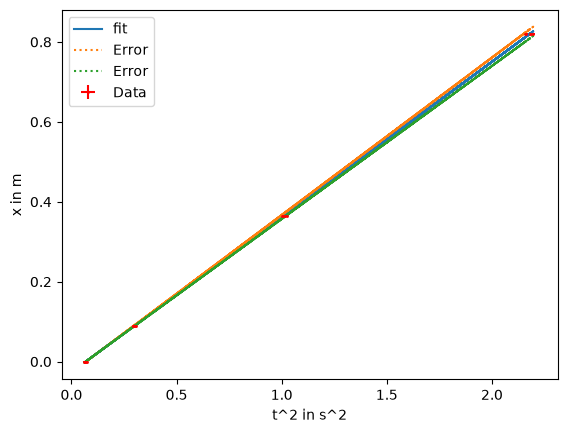

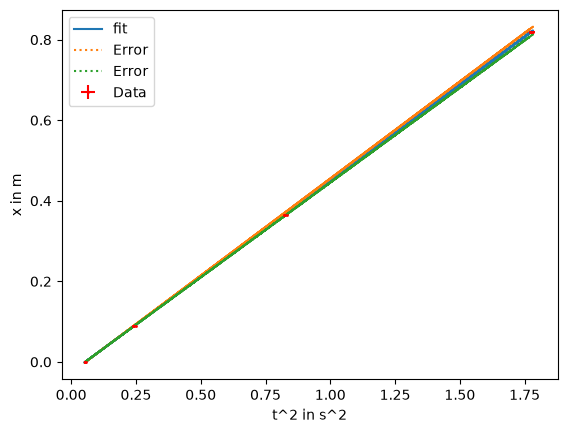

In [264]:
Abstände_5 = list(Abstände_Lichtschranken) * 5
HZ_fit = UCurve.ufit(nom(HZ_t_squared).flatten(),Abstände_5)
VZ_fit = UCurve.ufit(nom(VZ_t_squared).flatten(),Abstände_5)

HZ_fit.d_slope += 0.005
VZ_fit.d_slope += 0.005
HZ_fit.draw_avg_with_2Derrorbars(HZ_t_squared.flatten(),Abstände_5,xlabel="t^2 in s^2", ylabel="x in m",filename="/home/bergschaf/Pap/V15/Plot_HZ.svg")
VZ_fit.draw_avg_with_2Derrorbars(VZ_t_squared.flatten(),Abstände_5,xlabel="t^2 in s^2", ylabel="x in m",filename="/home/bergschaf/Pap/V15/Plot_VZ.svg")

In [260]:
HZ_a_experiment = HZ_fit.get_uslope() * 2
VZ_a_experiment = VZ_fit.get_uslope() * 2
g = ufloat(9.80984,2 * 10**(-5)) # result = np.repeat([arr], m, axis=0)TODO besserer Wert
VZ_a_rechnung = VZ_Masse * g * unp.sin(alpha) / (VZ_Masse * 3 / 2)
HZ_a_rechnung = HZ_Masse * g * unp.sin(alpha) / (HZ_Masse + 1/2 * HZ_Masse * (HZ_Radius_Außen**2 + HZ_Radius_Innen ** 2)/HZ_Radius_Außen**2 )

print(VZ_a_rechnung, VZ_a_experiment, SMD(VZ_a_rechnung, VZ_a_experiment))
print(HZ_a_rechnung, HZ_a_experiment, SMD(HZ_a_rechnung, HZ_a_experiment))
# Gut das Rechnung größer ist weil reibung


0.975+/-0.013 0.953+/-0.010 1.3790487399939364
0.800+/-0.011 0.777+/-0.010 1.5511709817236015


In [ ]:
"""
for i in range(5):
    t_squared = np.square(unp.uarray(HZ_Zeiten[i], [Unsicherheit_Zeitmessung] * 4))
    plt.errorbar(nom(t_squared),Abstände_Lichtschranken, xerr=std(t_squared),yerr=Unsicherheit_Abstandsmessung, fmt='.', color='black',
             ecolor='red', capsize=1)

for i in range(5):
    t_squared = np.square(unp.uarray(VZ_Zeiten[i], [Unsicherheit_Zeitmessung] * 4))
    plt.errorbar(nom(t_squared),Abstände_Lichtschranken, xerr=std(t_squared),yerr=Unsicherheit_Abstandsmessung, fmt=',', color='black',
             ecolor='red', capsize=1)


plt.xlabel("t^2 in s^2")
plt.ylabel("x in m")"""

# Energieerhaltung


In [ ]:
Rolldistanz = ufloat(87.3,0.1) / 100
h = unp.sin(alpha) * (Rolldistanz + VZ_Radius) + (VZ_Radius / unp.cos(alpha)) - VZ_Radius
# UUU Wichtig wir müssen da gucken dass wir die Höhe vom Schwerpunkt nehmen ne doch nicht weil wir sind immer 2cm höher
# uuu DOCH NICHT WEIL aufm graden isch der schwerpunkt nomml bissle höher
print(h)

D_Paar_1 = ufloat(0.0410,0.0001)
D_Paar_2 = ufloat(0.1490,0.0001)
# TODO Distanzen von Aaron abschreiben


In [ ]:

HZ_Zeiten_Geschwindigkeit = [
    [1.442,1.480,1.551,1.681],
    [1.449,1.187,1.558,1.689],
    [1.441,1.479,1.550,1.680],
    [1.443,1.481,1.553,1.684],
    [1.446,1.484,1.557,1.687]
]

VZ_Zeiten_Geschwindigkeit = [
    [1.310,1.344,1.409,1.528],
    [1.314,1.348,1.413,1.533],
    [1.314,1.349,1.414,1.536],
    [1.315,1.350,1.416,1.534],
    [1.309,1.343,1.409,1.531],
]
print([x[3] - x[2] for x in VZ_Zeiten_Geschwindigkeit])
print([x[3] - x[2] for x in HZ_Zeiten_Geschwindigkeit])

In [ ]:
# Geschwindigkeiten Ausrechnen
HZ_Geschwindigkeiten = []
for i in range(5):
    HZ_Geschwindigkeiten.append([D_Paar_1 / (ufloat(HZ_Zeiten_Geschwindigkeit[i][1],0.001) - ufloat(HZ_Zeiten_Geschwindigkeit[i][0],0.001)),D_Paar_2 / (ufloat(HZ_Zeiten_Geschwindigkeit[i][3],0.001) - ufloat(HZ_Zeiten_Geschwindigkeit[i][2],0.001))])

VZ_Geschwindigkeiten = []
for i in range(5):
    VZ_Geschwindigkeiten.append([D_Paar_1 / (ufloat(VZ_Zeiten_Geschwindigkeit[i][1],0.001) - ufloat(VZ_Zeiten_Geschwindigkeit[i][0],0.001)),D_Paar_2 / (ufloat(VZ_Zeiten_Geschwindigkeit[i][3],0.001) - ufloat(VZ_Zeiten_Geschwindigkeit[i][2],0.001))])

HZ_Geschwindigkeiten_unten = [x[1] for x in HZ_Geschwindigkeiten]
VZ_Geschwindigkeiten_unten = [x[1] for x in VZ_Geschwindigkeiten]


HZ_Geschwindigkeit = np.sum(HZ_Geschwindigkeiten_unten)/len(HZ_Geschwindigkeiten_unten)
VZ_Geschwindigkeit = np.sum(VZ_Geschwindigkeiten_unten)/len(VZ_Geschwindigkeiten_unten)

print(HZ_Geschwindigkeit, VZ_Geschwindigkeit)

In [ ]:
VZ_E_Pot = VZ_Masse * g * h
HZ_E_Pot = HZ_Masse * g * h

In [266]:
HZ_I = 1/2 * HZ_Masse * (HZ_Radius_Innen ** 2 + HZ_Radius_Außen ** 2)
HZ_E_Ges = 1/2 * HZ_Masse * HZ_Geschwindigkeit ** 2 + 1/2 * HZ_I * (HZ_Radius_Außen * HZ_Geschwindigkeit)**2

VZ_I = 1/2 * VZ_Masse * VZ_Radius ** 2
VZ_E_Ges = 1/2 * VZ_Masse * VZ_Geschwindigkeit ** 2 + 1/2 * VZ_I * (VZ_Radius * VZ_Geschwindigkeit)**2

print(HZ_E_Pot, HZ_E_Ges, SMD(HZ_E_Pot,HZ_E_Ges))
print(VZ_E_Pot, VZ_E_Ges, SMD(VZ_E_Pot,VZ_E_Ges))

0.583+/-0.008 0.2892+/-0.0029 34.94497106012744
0.585+/-0.008 0.341+/-0.004 27.84586327145498
